# Calendar and Temporal Feature Engineering

## Objective

This notebook performs calendar-based and temporal feature engineering
for the M5 retail sales forecasting dataset.

The goal is to transform the existing calendar information into
machine-learning-ready temporal features without using future sales
information.

### Features considered

- Year
- Month
- Week
- Day of month
- Day of week
- Quarter
- Weekend indicator
- Month-start indicator
- Month-end indicator
- Year-start indicator
- Year-end indicator
- Existing M5 calendar/event features

### Leakage prevention

Only calendar information available for each date is used.
No future sales values are used to construct these features.

In [87]:
import sys
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if 'google.colab' in sys.modules:
    BASE = Path("/content")
else:
    BASE = Path("..").resolve()

sys.path.insert(0, str(BASE / "src"))

PROCESSED_PATH = BASE / "data" / "m5" / "processed"
RESULTS_PATH = BASE / "results"
SRC_PATH = BASE / "src"

print("Libraries imported successfully.")

Libraries imported successfully.


In [88]:
calendar_clean = pd.read_csv(
    PROCESSED_PATH / "calendar_clean.csv"
)

print("Calendar shape:", calendar_clean.shape)
print("\nColumns:")
print(calendar_clean.columns.tolist())

Calendar shape: (1969, 14)

Columns:
['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']


In [89]:
calendar_clean["date"] = pd.to_datetime(
    calendar_clean["date"],
    errors="coerce"
)

print("Date dtype:", calendar_clean["date"].dtype)
print("Invalid dates:", calendar_clean["date"].isna().sum())

Date dtype: datetime64[us]
Invalid dates: 0


In [90]:
print("Minimum date:", calendar_clean["date"].min())
print("Maximum date:", calendar_clean["date"].max())
print("Number of dates:", calendar_clean["date"].nunique())

Minimum date: 2011-01-29 00:00:00
Maximum date: 2016-06-19 00:00:00
Number of dates: 1969


In [91]:
feature_file = SRC_PATH / "feature_engineering.py"

if not feature_file.exists():
    feature_file.write_text(
        '''from pathlib import Path
import pandas as pd
import numpy as np


def load_calendar(calendar_path):
    """
    Load the cleaned M5 calendar dataset.
    """
    calendar_path = Path(calendar_path)

    calendar = pd.read_csv(calendar_path)

    calendar["date"] = pd.to_datetime(
        calendar["date"],
        errors="coerce"
    )

    return calendar
''',
        encoding="utf-8"
    )

    print("feature_engineering.py created successfully.")
else:
    print("feature_engineering.py already exists.")

feature_engineering.py already exists.


In [92]:
feature_file = SRC_PATH / "feature_engineering.py"

current_code = feature_file.read_text(
    encoding="utf-8"
)

temporal_function = '''

def create_calendar_features(calendar):
    """
    Create calendar-based temporal features.

    Parameters
    ----------
    calendar : pandas.DataFrame
        Cleaned M5 calendar dataset.

    Returns
    -------
    pandas.DataFrame
        Calendar dataset with engineered temporal features.
    """

    df = calendar.copy()

    # Ensure date is datetime
    df["date"] = pd.to_datetime(
        df["date"],
        errors="coerce"
    )

    # Basic temporal features
    df["year_feature"] = df["date"].dt.year
    df["month_feature"] = df["date"].dt.month
    df["day_feature"] = df["date"].dt.day
    df["day_of_week_feature"] = df["date"].dt.dayofweek
    df["quarter_feature"] = df["date"].dt.quarter
    df["week_of_year_feature"] = df["date"].dt.isocalendar().week.astype(int)

    # Calendar boundary features
    df["is_weekend"] = (
        df["date"].dt.dayofweek >= 5
    ).astype(int)

    df["is_month_start"] = (
        df["date"].dt.is_month_start
    ).astype(int)

    df["is_month_end"] = (
        df["date"].dt.is_month_end
    ).astype(int)

    df["is_quarter_start"] = (
        df["date"].dt.is_quarter_start
    ).astype(int)

    df["is_quarter_end"] = (
        df["date"].dt.is_quarter_end
    ).astype(int)

    df["is_year_start"] = (
        df["date"].dt.is_year_start
    ).astype(int)

    df["is_year_end"] = (
        df["date"].dt.is_year_end
    ).astype(int)

    return df
'''

if "def create_calendar_features" not in current_code:
    feature_file.write_text(
        current_code + temporal_function,
        encoding="utf-8"
    )

    print("create_calendar_features() added successfully.")
else:
    print("create_calendar_features() already exists.")

create_calendar_features() already exists.


In [93]:
import importlib
import feature_engineering

importlib.reload(feature_engineering)

from feature_engineering import (
    load_calendar,
    create_calendar_features
)

print("Feature-engineering functions imported successfully.")

Feature-engineering functions imported successfully.


In [94]:
calendar_features = create_calendar_features(
    calendar_clean
)

print("Original shape:", calendar_clean.shape)
print("Feature-engineered shape:", calendar_features.shape)

Original shape: (1969, 14)
Feature-engineered shape: (1969, 27)


In [95]:
new_columns = [
    column
    for column in calendar_features.columns
    if column not in calendar_clean.columns
]

print("New temporal features:")
print("-" * 50)

for column in new_columns:
    print(column)

New temporal features:
--------------------------------------------------
year_feature
month_feature
day_feature
day_of_week_feature
quarter_feature
week_of_year_feature
is_weekend
is_month_start
is_month_end
is_quarter_start
is_quarter_end
is_year_start
is_year_end


In [96]:
calendar_features[
    [
        "date",
        "year_feature",
        "month_feature",
        "day_feature",
        "day_of_week_feature",
        "quarter_feature",
        "week_of_year_feature",
        "is_weekend"
    ]
].head(15)

,date,year_feature,month_feature,day_feature,day_of_week_feature,quarter_feature,week_of_year_feature,is_weekend
0,2011-01-29,2011,1,29,5,1,4,1
1,2011-01-30,2011,1,30,6,1,4,1
2,2011-01-31,2011,1,31,0,1,5,0
3,2011-02-01,2011,2,1,1,1,5,0
4,2011-02-02,2011,2,2,2,1,5,0
5,2011-02-03,2011,2,3,3,1,5,0
6,2011-02-04,2011,2,4,4,1,5,0
7,2011-02-05,2011,2,5,5,1,5,1
8,2011-02-06,2011,2,6,6,1,5,1
9,2011-02-07,2011,2,7,0,1,6,0


In [97]:
print("Temporal Feature Validation")
print("=" * 60)

print(
    "Missing dates:",
    calendar_features["date"].isna().sum()
)

print(
    "Missing year:",
    calendar_features["year_feature"].isna().sum()
)

print(
    "Missing month:",
    calendar_features["month_feature"].isna().sum()
)

print(
    "Missing day of week:",
    calendar_features["day_of_week_feature"].isna().sum()
)

print(
    "Missing weekend indicator:",
    calendar_features["is_weekend"].isna().sum()
)

Temporal Feature Validation
Missing dates: 0
Missing year: 0
Missing month: 0
Missing day of week: 0
Missing weekend indicator: 0


In [98]:
print("Feature Range Validation")
print("=" * 60)

print(
    "Month range:",
    calendar_features["month_feature"].min(),
    "to",
    calendar_features["month_feature"].max()
)

print(
    "Day range:",
    calendar_features["day_feature"].min(),
    "to",
    calendar_features["day_feature"].max()
)

print(
    "Day-of-week range:",
    calendar_features["day_of_week_feature"].min(),
    "to",
    calendar_features["day_of_week_feature"].max()
)

print(
    "Quarter range:",
    calendar_features["quarter_feature"].min(),
    "to",
    calendar_features["quarter_feature"].max()
)

print(
    "Weekend values:",
    sorted(calendar_features["is_weekend"].unique())
)

Feature Range Validation
Month range: 1 to 12
Day range: 1 to 31
Day-of-week range: 0 to 6
Quarter range: 1 to 4
Weekend values: [np.int64(0), np.int64(1)]


In [99]:
weekend_check = calendar_features[
    ["date", "day_of_week_feature", "is_weekend"]
].copy()

weekend_check.head(10)

,date,day_of_week_feature,is_weekend
0,2011-01-29,5,1
1,2011-01-30,6,1
2,2011-01-31,0,0
3,2011-02-01,1,0
4,2011-02-02,2,0
5,2011-02-03,3,0
6,2011-02-04,4,0
7,2011-02-05,5,1
8,2011-02-06,6,1
9,2011-02-07,0,0


In [100]:
print(
    "Incorrect weekend assignments:",
    (
        weekend_check["is_weekend"]
        != weekend_check["day_of_week_feature"].isin([5, 6]).astype(int)
    ).sum()
)

Incorrect weekend assignments: 0


In [101]:
print(
    "Dates sorted:",
    calendar_features["date"].is_monotonic_increasing
)

Dates sorted: True


In [102]:
print(
    "Duplicate dates:",
    calendar_features["date"].duplicated().sum()
)

Duplicate dates: 0


In [103]:
weekend_distribution = (
    calendar_features["is_weekend"]
    .value_counts()
    .sort_index()
)

print(weekend_distribution)

is_weekend
0    1405
1     564
Name: count, dtype: int64


In [104]:
monthly_distribution = (
    calendar_features["month_feature"]
    .value_counts()
    .sort_index()
)

print(monthly_distribution)

month_feature
1     158
2     170
3     186
4     180
5     186
6     169
7     155
8     155
9     150
10    155
11    150
12    155
Name: count, dtype: int64


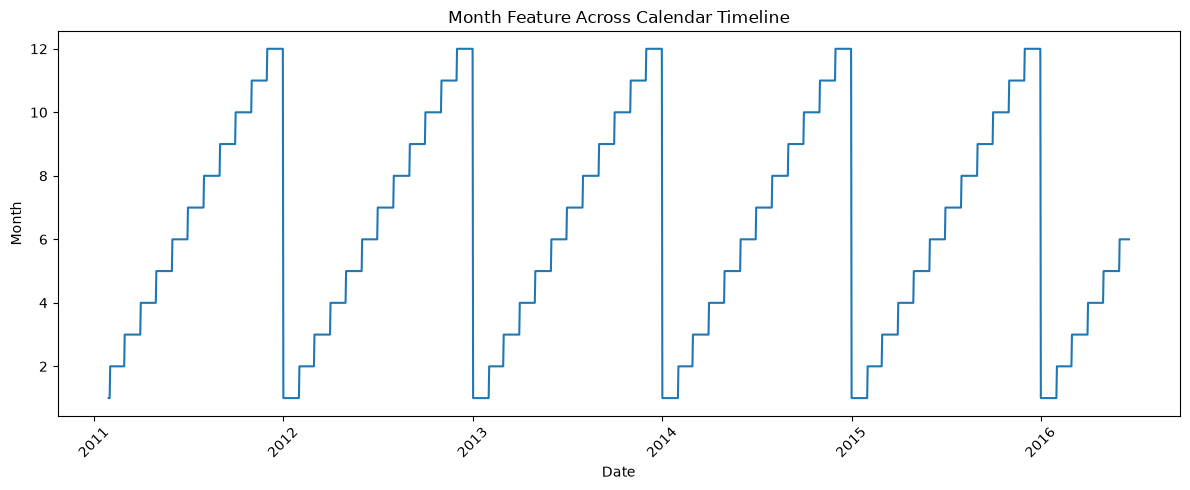

In [105]:
plt.figure(figsize=(12, 5))

plt.plot(
    calendar_features["date"],
    calendar_features["month_feature"]
)

plt.title("Month Feature Across Calendar Timeline")
plt.xlabel("Date")
plt.ylabel("Month")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [106]:
event_summary = pd.DataFrame({
    "event_name_1_non_none": [
        (calendar_features["event_name_1"] != "None").sum()
    ],
    "event_name_2_non_none": [
        (calendar_features["event_name_2"] != "None").sum()
    ]
}, index=[0])

display(event_summary)

print(
    calendar_features[
        calendar_features["event_name_1"] != "None"
    ][
        [
            "date",
            "event_name_1",
            "event_type_1"
        ]
    ].head(20)
)

,event_name_1_non_none,event_name_2_non_none
0,1969,1969


         date   event_name_1 event_type_1
0  2011-01-29            NaN          NaN
1  2011-01-30            NaN          NaN
2  2011-01-31            NaN          NaN
3  2011-02-01            NaN          NaN
4  2011-02-02            NaN          NaN
5  2011-02-03            NaN          NaN
6  2011-02-04            NaN          NaN
7  2011-02-05            NaN          NaN
8  2011-02-06      SuperBowl     Sporting
9  2011-02-07            NaN          NaN
10 2011-02-08            NaN          NaN
11 2011-02-09            NaN          NaN
12 2011-02-10            NaN          NaN
13 2011-02-11            NaN          NaN
14 2011-02-12            NaN          NaN
15 2011-02-13            NaN          NaN
16 2011-02-14  ValentinesDay     Cultural
17 2011-02-15            NaN          NaN
18 2011-02-16            NaN          NaN
19 2011-02-17            NaN          NaN


In [107]:
snap_columns = [
    "snap_CA",
    "snap_TX",
    "snap_WI"
]

print(
    calendar_features[snap_columns].sum()
)

print(
    calendar_features[snap_columns].value_counts()
    .head(10)
)

snap_CA    650
snap_TX    650
snap_WI    650
dtype: int64
snap_CA  snap_TX  snap_WI
0        0        0          994
1        1        1          260
0        1        1          195
1        1        0          130
         0        1          130
                  0          130
0        1        0           65
         0        1           65
Name: count, dtype: int64


In [108]:
feature_file = SRC_PATH / "feature_engineering.py"

current_code = feature_file.read_text(
    encoding="utf-8"
)

validation_function = '''

def validate_calendar_features(calendar):
    """
    Validate engineered calendar features.
    """

    required_features = [
        "year_feature",
        "month_feature",
        "day_feature",
        "day_of_week_feature",
        "quarter_feature",
        "week_of_year_feature",
        "is_weekend",
        "is_month_start",
        "is_month_end",
        "is_quarter_start",
        "is_quarter_end",
        "is_year_start",
        "is_year_end"
    ]

    missing_features = [
        feature
        for feature in required_features
        if feature not in calendar.columns
    ]

    validation = {
        "rows": len(calendar),
        "columns": len(calendar.columns),
        "missing_dates": int(
            calendar["date"].isna().sum()
        ),
        "duplicate_dates": int(
            calendar["date"].duplicated().sum()
        ),
        "dates_sorted": bool(
            calendar["date"].is_monotonic_increasing
        ),
        "missing_required_features": len(
            missing_features
        ),
        "invalid_month_values": int(
            (~calendar["month_feature"].between(1, 12)).sum()
        ),
        "invalid_day_of_week_values": int(
            (~calendar["day_of_week_feature"].between(0, 6)).sum()
        ),
        "invalid_quarter_values": int(
            (~calendar["quarter_feature"].between(1, 4)).sum()
        )
    }

    validation["missing_feature_names"] = missing_features

    return validation
'''

if "def validate_calendar_features" not in current_code:
    feature_file.write_text(
        current_code + validation_function,
        encoding="utf-8"
    )

    print("validate_calendar_features() added successfully.")
else:
    print("validate_calendar_features() already exists.")

validate_calendar_features() already exists.


In [109]:
importlib.reload(feature_engineering)

from feature_engineering import validate_calendar_features

calendar_validation = validate_calendar_features(
    calendar_features
)

print("Calendar Feature Validation")
print("=" * 60)

for key, value in calendar_validation.items():
    print(f"{key}: {value}")

Calendar Feature Validation
rows: 1969
columns: 27
missing_dates: 0
duplicate_dates: 0
dates_sorted: True
missing_required_features: 0
invalid_month_values: 0
invalid_day_of_week_values: 0
invalid_quarter_values: 0
missing_feature_names: []


In [110]:
feature_output_path = (
    PROCESSED_PATH
    / "calendar_features.csv"
)
feature_output_path.parent.mkdir(parents=True, exist_ok=True)

calendar_features.to_csv(
    feature_output_path,
    index=False
)

print(
    "Saved:",
    feature_output_path
)

Saved: E:\dl-assignment\data\m5\processed\calendar_features.csv


In [111]:
validation_output_path = (
    RESULTS_PATH / "calendar_feature_validation.csv"
)
validation_output_path.parent.mkdir(parents=True, exist_ok=True)

pd.DataFrame([calendar_validation]).to_csv(
    validation_output_path,
    index=False
)

print(
    "Saved:",
    validation_output_path
)

Saved: E:\dl-assignment\results\calendar_feature_validation.csv


In [112]:
assert calendar_validation["missing_dates"] == 0
assert calendar_validation["duplicate_dates"] == 0
assert calendar_validation["dates_sorted"] is True
assert calendar_validation["missing_required_features"] == 0
assert calendar_validation["invalid_month_values"] == 0
assert calendar_validation["invalid_day_of_week_values"] == 0
assert calendar_validation["invalid_quarter_values"] == 0

print("All calendar feature-engineering checks passed.")

All calendar feature-engineering checks passed.


In [113]:
print("Final Calendar Feature Set")
print("=" * 60)

for i, column in enumerate(calendar_features.columns, start=1):
    print(f"{i:02d}. {column}")

Final Calendar Feature Set
01. date
02. wm_yr_wk
03. weekday
04. wday
05. month
06. year
07. d
08. event_name_1
09. event_type_1
10. event_name_2
11. event_type_2
12. snap_CA
13. snap_TX
14. snap_WI
15. year_feature
16. month_feature
17. day_feature
18. day_of_week_feature
19. quarter_feature
20. week_of_year_feature
21. is_weekend
22. is_month_start
23. is_month_end
24. is_quarter_start
25. is_quarter_end
26. is_year_start
27. is_year_end
